# Analyses sur les truites et leurs caractéristiques

## Importation des packages

In [1]:
import pandas as pd
import numpy as np
import sys
from pathlib import Path

sys.path.append(str(Path.cwd().parent)) # Ajoute le dossier parent au chemin de recherche de Python

from utils.stats_fct import distribution, nuage_points, linear_regression

## Importation des metadatas

In [2]:
data = pd.read_excel('../utils/correspondance_echo_final.xlsx')

data_unique = data.drop_duplicates("cap_id")
data_unique

,annee,cap_id,long_gonade,type_image,name_file,image_id,new_name_file,position,position_ratio,categorie,categories,age_poisson,poids_poisson,long_poisson,echelle
0,2019,356282,5.0,op+1,10.13.22 h __[0004569],4569,0004569_10.13.22_356282_2019,1.0,0.200000,debut,"['debut', 'milieu']",NaN,74.9,186,NaN
3,2019,356302,7.1,op+1,10.29.35 h __[0004572],4572,0004572_10.29.35_356302_2019,1.0,0.140845,debut,"['debut', 'milieu', 'milieu']",NaN,65.6,176,3.1
7,2019,356323,3.9,op0,10.50.21 h __[0004576],4576,0004576_10.50.21_356323_2019,0.0,0.000000,debut,"['debut', 'milieu', 'fin']",NaN,46.4,155,NaN
10,2019,356418,8.2,op0,12.06.43 h __[0004586],4586,0004586_12.06.43_356418_2019,0.0,0.000000,debut,"['debut', 'milieu', 'milieu', 'fin']",2+,95.7,205,3.8
15,2019,356430,8.5,op0,12.15.09 h __[0004592],4592,0004592_12.15.09_356430_2019,0.0,0.000000,debut,"['debut', 'milieu', 'milieu', 'fin']",2+,128.9,223,3.8
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1175,2025,444018,7.2,op0,17.48.15 h __[0009013],9013,0009013_17.48.15_444018_2025,0.0,0.000000,debut,"['debut', 'milieu', 'milieu', 'fin']",.,146.1,243,NaN
1181,2025,444039,8.2,op0,09.49.43 h __[0009026],9026,0009026_09.49.43_444039_2025,0.0,0.000000,debut,"['debut', 'milieu', 'milieu', 'fin']",2+,125.8,232,NaN
1187,2025,444128,4.8,op0,11.00.49 h __[0009057],9057,0009057_11.00.49_444128_2025,0.0,0.000000,debut,"['debut', 'milieu', 'fin']",1+,62.5,176,NaN
1192,2025,444284,10.0,op0,13.58.29 h __[0009094],9094,0009094_13.58.29_444284_2025,0.0,0.000000,debut,"['debut', 'milieu', 'milieu', 'milieu', 'fin']",3+,203.4,264,NaN


### Distribution d'une variable

- Regarder la forme : symmétrique ? étirée vers la gauche ou la droite ? moyenne, répartition ?

### Modèle linéaire

Influence plot :
- **Leverage** : un point très à droite a un fort levier (valeur extrême par rapport aux autres)
- **Résidus** : un point très haut ou très bas (-2/2) est mal prédit
- **Distance de Cook** : impact du point sur la droit si on le supprimait : combinaison leverage et résidus (taille des bulles) 

Résidus vs valeurs prédites :
- Regarder si structures dans les résidus

## Statistiques descriptives

### Stats distribution poissons

In [3]:
# Nombre de poissons
print(f"Nombre de poissons : {len(data_unique)}")

# Nombre de poissons par année
print(f"Nombre de poissons par année : \n {data_unique.groupby('annee').size()}")


Nombre de poissons : 243
Nombre de poissons par année : 
 annee
2019    32
2020    37
2021    18
2022    20
2023    54
2024    47
2025    35
dtype: int64


### Stats distributions échographies

In [4]:
# Nombre d'échographies
print(f"Nombre d'échographies : {len(data)}")

# Nombre d'échographies par année
print(f"Nombre d'échographies par année :")
print(data.groupby("annee").size())

Nombre d'échographies : 1204
Nombre d'échographies par année :
annee
2019    145
2020    183
2021     85
2022    104
2023    283
2024    215
2025    189
dtype: int64


### Distribution nombre d'échographies par poisson

In [5]:
data_oeufs = data[data["type_image"] == "œufs"]
data_cavite = data[data["type_image"] != "œufs"]

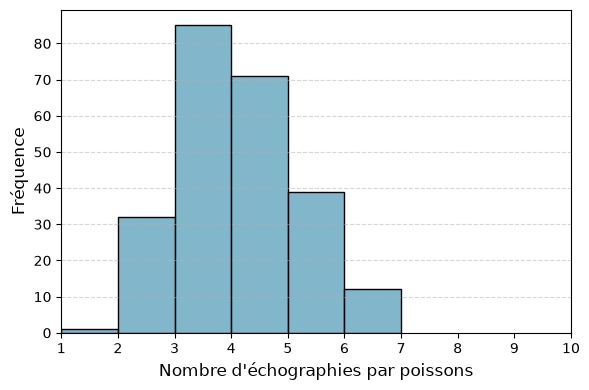

Nombre d'échographies moyennes par poissons : 
 3.6333333333333333
Répartition des échographies par poissons : 
 3    85
4    71
5    39
2    32
6    11
7     1
1     1
Name: count, dtype: int64


In [6]:
echographies_per_fish = data_cavite.groupby("cap_id").size()

plot = distribution(donnees = echographies_per_fish, 
             xlabel="Nombre d'échographies par poissons", 
             titre="",
             couleur = "#63A5BF",
             axe_x_fixe = (1,10,1),
             nombre_barres = 6,
             afficher_courbe = False
             )
print(f"Nombre d'échographies moyennes par poissons : \n {np.mean(echographies_per_fish)}")
print(f"Répartition des échographies par poissons : \n {echographies_per_fish.value_counts()}")
plot.figure.savefig("Distribution_echo.pdf", format="pdf", bbox_inches="tight")

### Distribution de la taille des poissons (longueur fourche)

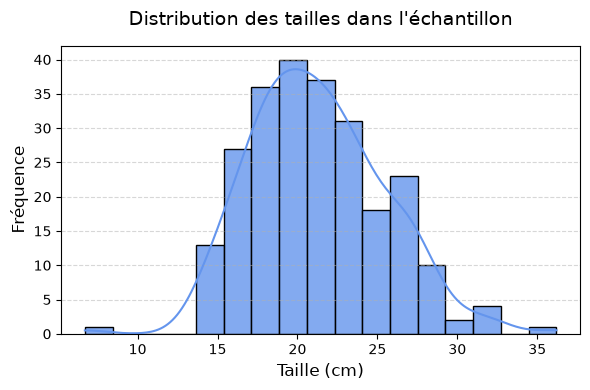

Taille moyenne des poissons : 21.260493827160495 cm
Taille min et max des poissons : 6.7 cm et 36.2 cm


In [9]:
distribution(
    donnees=data_unique.long_poisson/10, 
    titre="Distribution des tailles dans l'échantillon", 
    xlabel="Taille (cm)"
)
print(f"Taille moyenne des poissons : {np.mean(data_unique.long_poisson)/10} cm")
print(f"Taille min et max des poissons : {np.min(data_unique.long_poisson)/10} cm et {np.max(data_unique.long_poisson)/10} cm")

### Distribution des poids dans la population

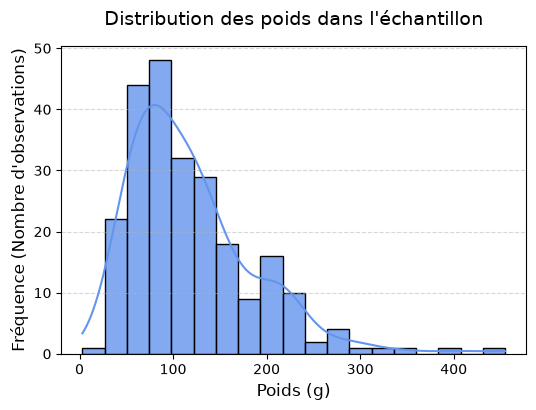

In [7]:
distribution(
    donnees=data_unique.poids_poisson, 
    titre="Distribution des poids dans l'échantillon", 
    xlabel="Poids (g)"
)

### Distribution longueur des gonades

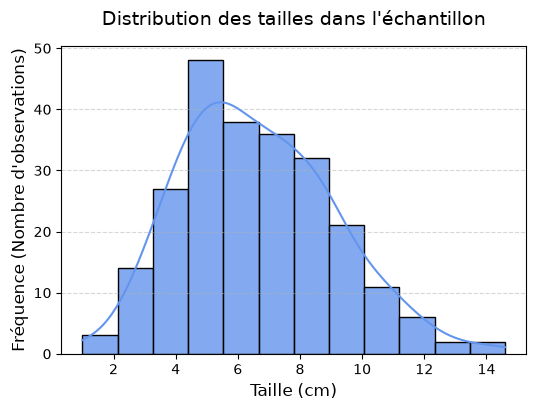

In [8]:
distribution(
    donnees=data_unique.long_gonade, 
    titre="Distribution des tailles dans l'échantillon", 
    xlabel="Taille (cm)"
)

### Distribution age poissons

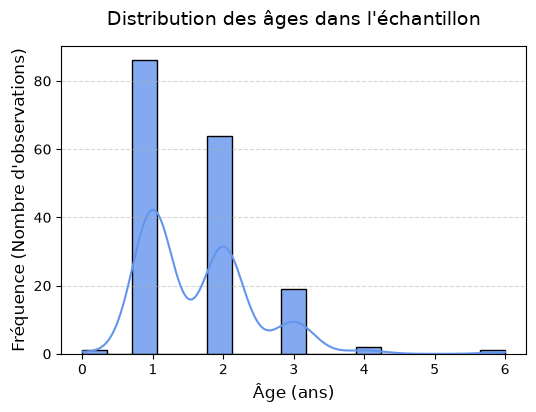

In [29]:
age_poisson = [float((str(age).split("+")[0]).replace(".", "nan")) for age in data_unique.age_poisson]

distribution(
    donnees=age_poisson, 
    titre="Distribution des âges dans l'échantillon", 
    xlabel="Âge (ans)"
)

In [59]:
reste = [str(age).split("+")[1] if len(str(age).split("+")) > 1 else None for age in data_unique.age_poisson]
age_fecondité = [list(r) for r in reste if r is not None and r != '']

### Taille / poids des poissons

Corrélation : 0.9917931275431217


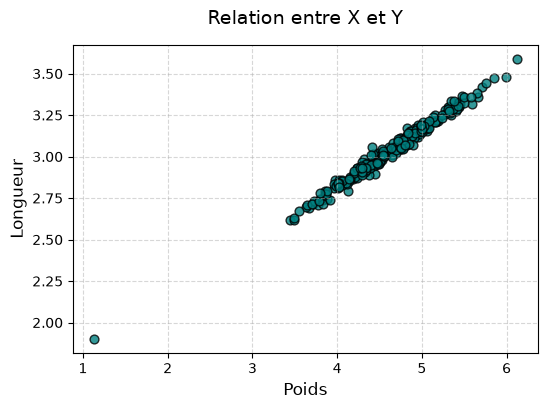

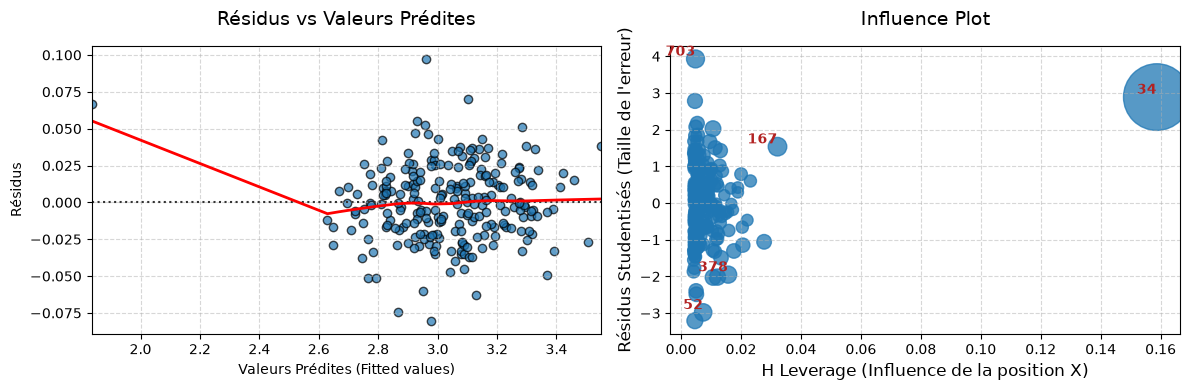

In [60]:
print(f"Corrélation : {np.log(data_unique.poids_poisson).corr(np.log(data_unique.long_poisson/10))}") # Corrélation

nuage_points(
    x=np.log(data_unique.poids_poisson), 
    y=np.log(data_unique.long_poisson/10), 
    titre="Relation entre X et Y", 
    xlabel="Poids", 
    ylabel="Longueur",
    couleur='teal'
)

# Tranformations logarithmiques car non linéaire
linear_regression(np.log(data_unique.poids_poisson), np.log(data_unique.long_poisson/10))

In [61]:
# Analyse des outliers et influence
data_unique.loc[34]

annee                                             2019
cap_id                                          356694
long_gonade                                        7.5
type_image                                         op0
name_file                       16.29.36 h __[0004631]
image_id                                        4631.0
new_name_file             0004631_16.29.36_356694_2019
position                                           0.0
position_ratio                                     0.0
categorie                                        debut
categories        ['debut', 'milieu', 'milieu', 'fin']
poids_poisson                                      3.1
long_poisson                                        67
age_poisson                                         0+
echelle                                            NaN
Name: 34, dtype: object

### Longeur gonade / longueur

Corrélation : 0.825070414142751


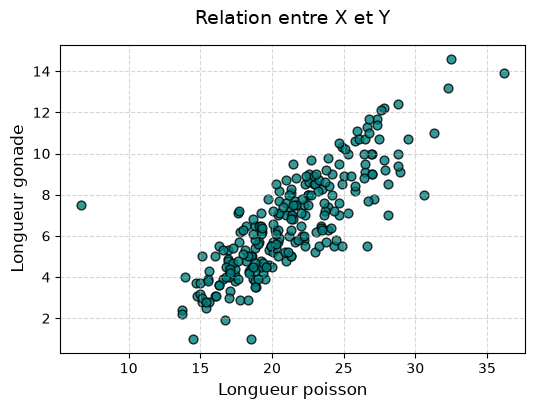

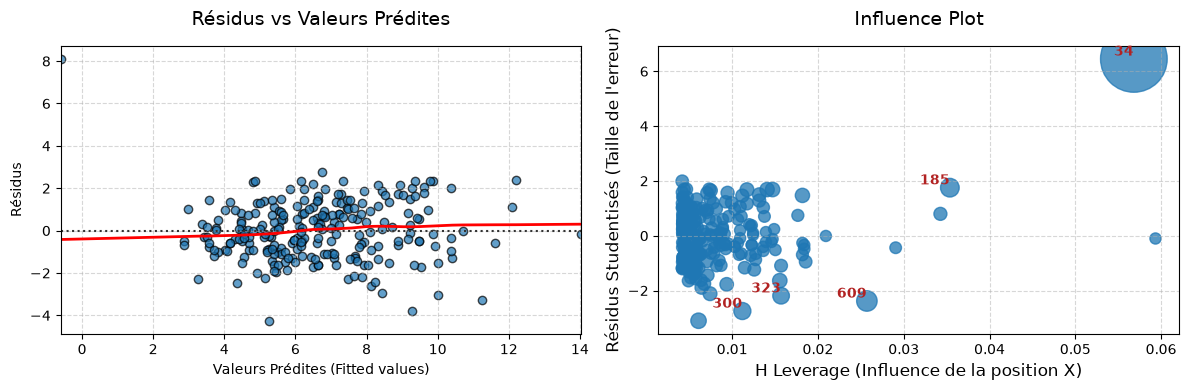

In [ ]:
print(f"Corrélation : {data_unique.long_gonade.corr(data_unique.long_poisson/10)}") # Corrélation

nuage_points(
    x=data_unique.long_poisson/10, 
    y=data_unique.long_gonade, 
    titre="Relation entre X et Y", 
    xlabel="Longueur poisson", 
    ylabel="Longueur gonade",
    couleur='teal'
)

# Tranformations logarithmiques car non linéaire
linear_regression(data_unique.long_poisson/10, data_unique.long_gonade)

In [ ]:
# Outliers et influence
data_unique.loc[609]

NameError: name 'data' is not defined

### Longueur gonade / poids

Corrélation : 0.845240699831284


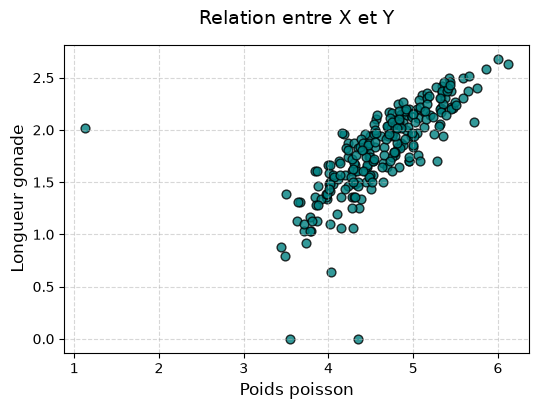

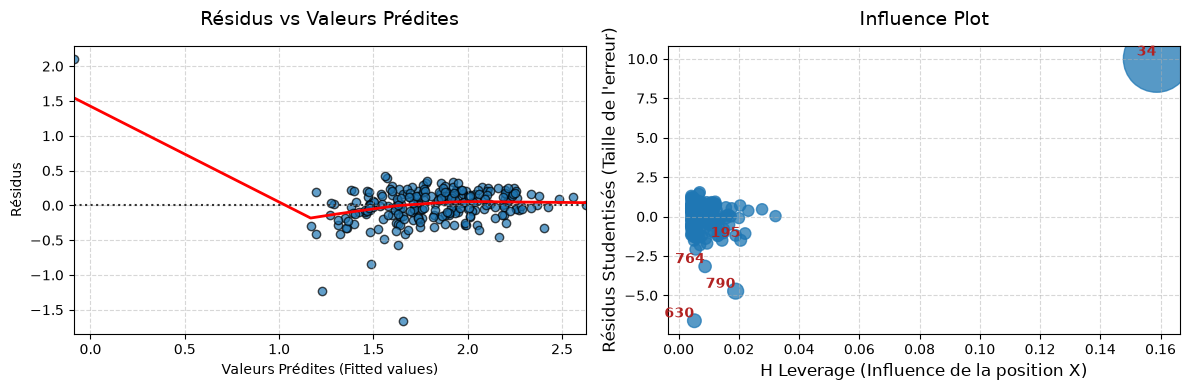

In [34]:
print(f"Corrélation : {data_unique.long_gonade.corr(data_unique.poids_poisson)}") # Corrélation

nuage_points(
    x=np.log(data_unique.poids_poisson), 
    y=np.log(data_unique.long_gonade), 
    titre="Relation entre X et Y", 
    xlabel="Poids poisson", 
    ylabel="Longueur gonade",
    couleur='teal'
)

# Tranformations logarithmiques car non linéaire
linear_regression(np.log(data_unique.poids_poisson), np.log(data_unique.long_gonade))